In [1]:
import joblib
from taxipred.utils.constants import MODEL

model = joblib.load(MODEL)
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [2]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import LinearRegression

# Load the model
model = joblib.load(MODEL)

# Define the expected feature order (from training)
EXPECTED_FEATURES = [
    'trip_distance_km', 
    'trip_duration_minutes', 
    'time_of_day_Evening', 
    'time_of_day_Morning', 
    'time_of_day_Night', 
    'day_of_week_Weekend', 
    'traffic_conditions_Low', 
    'traffic_conditions_Medium', 
    'weather_Rain', 
    'weather_Snow'
]

# Categorical columns
CAT_COLUMNS = ['time_of_day', 'day_of_week', 'traffic_conditions', 'weather']
NUM_COLUMNS = ['trip_distance_km', 'trip_duration_minutes']

print("Model loaded successfully!")
print(f"Model expects {len(EXPECTED_FEATURES)} features")
print(f"Features: {EXPECTED_FEATURES}")

Model loaded successfully!
Model expects 10 features
Features: ['trip_distance_km', 'trip_duration_minutes', 'time_of_day_Evening', 'time_of_day_Morning', 'time_of_day_Night', 'day_of_week_Weekend', 'traffic_conditions_Low', 'traffic_conditions_Medium', 'weather_Rain', 'weather_Snow']


In [3]:
def preprocess_input(data, mice_imputer=None, cat_imputer=None):
    """
    Preprocess input data to match the model's expected format.
    
    Parameters:
    -----------
    data : dict or pd.DataFrame
        Input data with keys/columns: trip_distance_km, trip_duration_minutes,
        time_of_day, day_of_week, traffic_conditions, weather
    mice_imputer : IterativeImputer, optional
        Fitted MICE imputer for numerical columns. If None, will create a new one.
    cat_imputer : SimpleImputer, optional
        Fitted categorical imputer. If None, will use most_frequent strategy.
    
    Returns:
    --------
    pd.DataFrame: Preprocessed data ready for model prediction
    """
    # Convert to DataFrame if dict
    if isinstance(data, dict):
        df = pd.DataFrame([data])
    else:
        df = data.copy()
    
    # Ensure all required columns exist
    required_cols = NUM_COLUMNS + CAT_COLUMNS
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    # Separate numerical and categorical
    X_num = df[NUM_COLUMNS].copy()
    X_cat = df[CAT_COLUMNS].copy()
    
    # Impute numerical columns (if imputer provided, use it; otherwise fit new one)
    if mice_imputer is None:
        mice_imputer = IterativeImputer(
            estimator=LinearRegression(),
            random_state=42,
            max_iter=20,
            sample_posterior=False
        )
        X_num_imp = pd.DataFrame(
            mice_imputer.fit_transform(X_num),
            columns=NUM_COLUMNS,
            index=X_num.index
        )
    else:
        X_num_imp = pd.DataFrame(
            mice_imputer.transform(X_num),
            columns=NUM_COLUMNS,
            index=X_num.index
        )
    
    # Impute categorical columns
    if cat_imputer is None:
        cat_imputer = SimpleImputer(strategy="most_frequent")
        X_cat_imp = pd.DataFrame(
            cat_imputer.fit_transform(X_cat),
            columns=CAT_COLUMNS,
            index=X_cat.index
        )
    else:
        X_cat_imp = pd.DataFrame(
            cat_imputer.transform(X_cat),
            columns=CAT_COLUMNS,
            index=X_cat.index
        )
    
    # Combine imputed data
    X_imputed = pd.concat([X_num_imp, X_cat_imp], axis=1)
    
    # Create dummy variables (drop_first=True to match training)
    X_dummies = pd.get_dummies(X_imputed, columns=CAT_COLUMNS, drop_first=True)
    
    # Ensure all expected features exist (fill missing with 0)
    for feature in EXPECTED_FEATURES:
        if feature not in X_dummies.columns:
            X_dummies[feature] = 0
    
    # Reorder columns to match expected feature order
    X_final = X_dummies[EXPECTED_FEATURES]
    
    return X_final

print("Preprocessing function defined!")

Preprocessing function defined!


In [4]:
# Example: Test with real values
# Valid categorical values:
# - time_of_day: 'Morning', 'Evening', 'Afternoon', 'Night' (reference category is dropped)
# - day_of_week: 'Weekday', 'Weekend' (Weekday is reference, so only Weekend appears in features)
# - traffic_conditions: 'Low', 'Medium', 'High' (High is reference, so only Low/Medium appear)
# - weather: 'Clear', 'Rain', 'Snow' (Clear is reference, so only Rain/Snow appear)

test_data = {
    'trip_distance_km': 15.5,
    'trip_duration_minutes': 30.0,
    'time_of_day': 'Evening',  # Options: 'Morning', 'Evening', 'Afternoon', 'Night'
    'day_of_week': 'Weekend',  # Options: 'Weekend', 'Weekday'
    'traffic_conditions': 'Medium',  # Options: 'Low', 'Medium', 'High'
    'weather': 'Rain'  # Options: 'Rain', 'Snow', 'Clear'
}

# Preprocess the input
X_processed = preprocess_input(test_data)

print("Processed input:")
print(X_processed)
print(f"\nShape: {X_processed.shape}")
print(f"Features match expected: {list(X_processed.columns) == EXPECTED_FEATURES}")

# Make prediction
prediction = model.predict(X_processed)
print(f"\nPredicted trip price: ${prediction[0]:.2f}")

Processed input:
   trip_distance_km  trip_duration_minutes  time_of_day_Evening  \
0              15.5                   30.0                    0   

   time_of_day_Morning  time_of_day_Night  day_of_week_Weekend  \
0                    0                  0                    0   

   traffic_conditions_Low  traffic_conditions_Medium  weather_Rain  \
0                       0                          0             0   

   weather_Snow  
0             0  

Shape: (1, 10)
Features match expected: True

Predicted trip price: $31.52


In [5]:
# Test with multiple examples
test_cases = [
    {
        'trip_distance_km': 10.0,
        'trip_duration_minutes': 20.0,
        'time_of_day': 'Morning',
        'day_of_week': 'Weekday',  # Reference category (won't appear in dummy)
        'traffic_conditions': 'Low',
        'weather': 'Clear'  # Reference category (won't appear in dummy)
    },
    {
        'trip_distance_km': 25.0,
        'trip_duration_minutes': 45.0,
        'time_of_day': 'Night',
        'day_of_week': 'Weekend',
        'traffic_conditions': 'High',  # Reference category (won't appear in dummy)
        'weather': 'Snow'
    },
    {
        'trip_distance_km': 5.0,
        'trip_duration_minutes': 15.0,
        'time_of_day': 'Afternoon',
        'day_of_week': 'Weekend',
        'traffic_conditions': 'Medium',
        'weather': 'Rain'
    }
]

# Process all test cases
X_batch = preprocess_input(pd.DataFrame(test_cases))
predictions = model.predict(X_batch)

print("Batch predictions:")
for i, (test_case, pred) in enumerate(zip(test_cases, predictions), 1):
    print(f"\nTest Case {i}:")
    print(f"  Distance: {test_case['trip_distance_km']} km")
    print(f"  Duration: {test_case['trip_duration_minutes']} min")
    print(f"  Time: {test_case['time_of_day']}, Day: {test_case['day_of_week']}")
    print(f"  Traffic: {test_case['traffic_conditions']}, Weather: {test_case['weather']}")
    print(f"  Predicted Price: ${pred:.2f}")

Batch predictions:

Test Case 1:
  Distance: 10.0 km
  Duration: 20.0 min
  Time: Morning, Day: Weekday
  Traffic: Low, Weather: Clear
  Predicted Price: $16.59

Test Case 2:
  Distance: 25.0 km
  Duration: 45.0 min
  Time: Night, Day: Weekend
  Traffic: High, Weather: Snow
  Predicted Price: $60.16

Test Case 3:
  Distance: 5.0 km
  Duration: 15.0 min
  Time: Afternoon, Day: Weekend
  Traffic: Medium, Weather: Rain
  Predicted Price: $14.07


In [6]:
# Test with actual data from the original CSV
from taxipred.utils.constants import TAXI_CSV_PATH

# Load the original data
df_original = pd.read_csv(TAXI_CSV_PATH)

# Rename columns to match our model's expected format (lowercase with underscores)
df_original.columns = df_original.columns.str.lower().str.replace(' ', '_')

print(f"Loaded {len(df_original)} rows from original data")
print(f"\nColumns: {list(df_original.columns)}")
print(f"\nFirst few rows:")
df_original.head()

Loaded 1000 rows from original data

Columns: ['trip_distance_km', 'time_of_day', 'day_of_week', 'passenger_count', 'traffic_conditions', 'weather', 'base_fare', 'per_km_rate', 'per_minute_rate', 'trip_duration_minutes', 'trip_price']

First few rows:


,trip_distance_km,time_of_day,day_of_week,passenger_count,traffic_conditions,weather,base_fare,per_km_rate,per_minute_rate,trip_duration_minutes,trip_price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [7]:
# Select rows that have all required features and a trip_price
# Map column names from original CSV to our model's expected format
column_mapping = {
    'trip_distance_km': 'trip_distance_km',
    'trip_duration_minutes': 'trip_duration_minutes',
    'time_of_day': 'time_of_day',
    'day_of_week': 'day_of_week',
    'traffic_conditions': 'traffic_conditions',
    'weather': 'weather',
    'trip_price': 'trip_price'
}

# Check which columns exist
available_cols = df_original.columns.tolist()
print("Available columns:", available_cols)

# Find rows with complete data (all features + trip_price)
required_features = ['trip_distance_km', 'trip_duration_minutes', 'time_of_day', 
                    'day_of_week', 'traffic_conditions', 'weather', 'trip_price']

# Filter for rows that have all required columns and non-null trip_price
complete_rows = df_original.dropna(subset=required_features)

print(f"\nRows with complete data: {len(complete_rows)} out of {len(df_original)}")
print(f"\nSample of complete rows:")
complete_rows[required_features].head(10)

Available columns: ['trip_distance_km', 'time_of_day', 'day_of_week', 'passenger_count', 'traffic_conditions', 'weather', 'base_fare', 'per_km_rate', 'per_minute_rate', 'trip_duration_minutes', 'trip_price']

Rows with complete data: 693 out of 1000

Sample of complete rows:


,trip_distance_km,trip_duration_minutes,time_of_day,day_of_week,traffic_conditions,weather,trip_price
0,19.35,53.82,Morning,Weekday,Low,Clear,36.2624
2,36.87,37.27,Evening,Weekend,High,Clear,52.9032
5,8.64,89.33,Afternoon,Weekend,Medium,Clear,60.2028
6,3.85,5.05,Afternoon,Weekday,High,Rain,11.2645
12,41.79,86.95,Night,Weekend,High,Clear,88.1328
14,9.91,41.72,Evening,Weekday,High,Clear,28.9914
15,9.99,34.00,Night,Weekday,High,Clear,27.4415
16,15.91,114.93,Morning,Weekday,Low,Clear,56.7160
17,26.71,111.18,Afternoon,Weekend,Low,Rain,69.0049
20,30.98,57.02,Afternoon,Weekend,Low,Rain,44.7782


In [8]:
# Test predictions on actual data
# Select a few random examples with actual trip prices
test_samples = complete_rows.sample(min(10, len(complete_rows)), random_state=42)

print("Testing model on actual data samples:\n")
print("=" * 80)

predictions_list = []
actual_prices = []

for idx, row in test_samples.iterrows():
    # Prepare input data (exclude trip_price)
    input_data = {
        'trip_distance_km': row['trip_distance_km'],
        'trip_duration_minutes': row['trip_duration_minutes'],
        'time_of_day': row['time_of_day'],
        'day_of_week': row['day_of_week'],
        'traffic_conditions': row['traffic_conditions'],
        'weather': row['weather']
    }
    
    # Preprocess and predict
    X_processed = preprocess_input(input_data)
    prediction = model.predict(X_processed)[0]
    
    actual_price = row['trip_price']
    predictions_list.append(prediction)
    actual_prices.append(actual_price)
    
    error = abs(prediction - actual_price)
    error_pct = (error / actual_price) * 100 if actual_price > 0 else 0
    
    print(f"Sample {idx}:")
    print(f"  Distance: {row['trip_distance_km']:.2f} km | Duration: {row['trip_duration_minutes']:.2f} min")
    print(f"  Time: {row['time_of_day']} | Day: {row['day_of_week']}")
    print(f"  Traffic: {row['traffic_conditions']} | Weather: {row['weather']}")
    print(f"  Actual Price: ${actual_price:.2f}")
    print(f"  Predicted Price: ${prediction:.2f}")
    print(f"  Error: ${error:.2f} ({error_pct:.1f}%)")
    print("-" * 80)

# Calculate overall metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(actual_prices, predictions_list)
rmse = np.sqrt(mean_squared_error(actual_prices, predictions_list))
r2 = r2_score(actual_prices, predictions_list)
mean_ape = np.mean([abs(p - a) / a * 100 if a > 0 else 0 
                    for p, a in zip(predictions_list, actual_prices)])

print(f"\n{'=' * 80}")
print(f"Overall Performance Metrics:")
print(f"  MAE (Mean Absolute Error): ${mae:.2f}")
print(f"  RMSE (Root Mean Squared Error): ${rmse:.2f}")
print(f"  R² Score: {r2:.4f}")
print(f"  Mean Absolute Percentage Error: {mean_ape:.1f}%")
print(f"{'=' * 80}")

Testing model on actual data samples:

Sample 560:
  Distance: 35.50 km | Duration: 111.09 min
  Time: Afternoon | Day: Weekend
  Traffic: Low | Weather: Rain
  Actual Price: $109.90
  Predicted Price: $90.35
  Error: $19.55 (17.8%)
--------------------------------------------------------------------------------
Sample 962:
  Distance: 13.02 km | Duration: 89.60 min
  Time: Evening | Day: Weekday
  Traffic: High | Weather: Clear
  Actual Price: $48.01
  Predicted Price: $47.55
  Error: $0.46 (1.0%)
--------------------------------------------------------------------------------
Sample 387:
  Distance: 9.69 km | Duration: 85.28 min
  Time: Morning | Day: Weekday
  Traffic: Medium | Weather: Clear
  Actual Price: $37.00
  Predicted Price: $38.45
  Error: $1.45 (3.9%)
--------------------------------------------------------------------------------
Sample 507:
  Distance: 41.30 km | Duration: 71.50 min
  Time: Afternoon | Day: Weekday
  Traffic: Medium | Weather: Rain
  Actual Price: $37.1

In [9]:
# Test: Can the model predict above $122.13?
# Let's test with very long distances to see if predictions are capped

test_extreme_cases = [
    {
        'trip_distance_km': 50.0,  # Long distance
        'trip_duration_minutes': 60.0,
        'time_of_day': 'Evening',
        'day_of_week': 'Weekend',
        'traffic_conditions': 'High',
        'weather': 'Rain'
    },
    {
        'trip_distance_km': 100.0,  # Very long distance
        'trip_duration_minutes': 90.0,
        'time_of_day': 'Night',
        'day_of_week': 'Weekend',
        'traffic_conditions': 'High',
        'weather': 'Snow'
    },
    {
        'trip_distance_km': 150.0,  # Extremely long distance
        'trip_duration_minutes': 120.0,
        'time_of_day': 'Afternoon',
        'day_of_week': 'Weekday',
        'traffic_conditions': 'Medium',
        'weather': 'Clear'
    },
    {
        'trip_distance_km': 200000.0,  # Super long distance
        'trip_duration_minutes': 150000.0,
        'time_of_day': 'Morning',
        'day_of_week': 'Weekend',
        'traffic_conditions': 'Low',
        'weather': 'Clear'
    }
]

print("Testing if predictions are capped at $122.13:\n")
print("=" * 80)

for i, test_case in enumerate(test_extreme_cases, 1):
    X_processed = preprocess_input(test_case)
    prediction = model.predict(X_processed)[0]
    
    print(f"Test Case {i}:")
    print(f"  Distance: {test_case['trip_distance_km']} km")
    print(f"  Duration: {test_case['trip_duration_minutes']} min")
    print(f"  Predicted Price: ${prediction:.2f}")
    print(f"  Above threshold ($122.13)? {'YES' if prediction > 122.13 else 'NO'}")
    print("-" * 80)

print(f"\n{'=' * 80}")
print("CONCLUSION:")
print("The model CAN predict above $122.13, but it was trained on winsorized data")
print("where the maximum target value was $122.13.")
print("So while it can predict higher values, it may not be accurate for")
print("extreme cases since it never learned from such examples.")
print(f"{'=' * 80}")

Testing if predictions are capped at $122.13:

Test Case 1:
  Distance: 50.0 km
  Duration: 60.0 min
  Predicted Price: $83.18
  Above threshold ($122.13)? NO
--------------------------------------------------------------------------------
Test Case 2:
  Distance: 100.0 km
  Duration: 90.0 min
  Predicted Price: $79.80
  Above threshold ($122.13)? NO
--------------------------------------------------------------------------------
Test Case 3:
  Distance: 150.0 km
  Duration: 120.0 min
  Predicted Price: $75.91
  Above threshold ($122.13)? NO
--------------------------------------------------------------------------------
Test Case 4:
  Distance: 200000.0 km
  Duration: 150000.0 min
  Predicted Price: $75.91
  Above threshold ($122.13)? NO
--------------------------------------------------------------------------------

CONCLUSION:
The model CAN predict above $122.13, but it was trained on winsorized data
where the maximum target value was $122.13.
So while it can predict higher values,

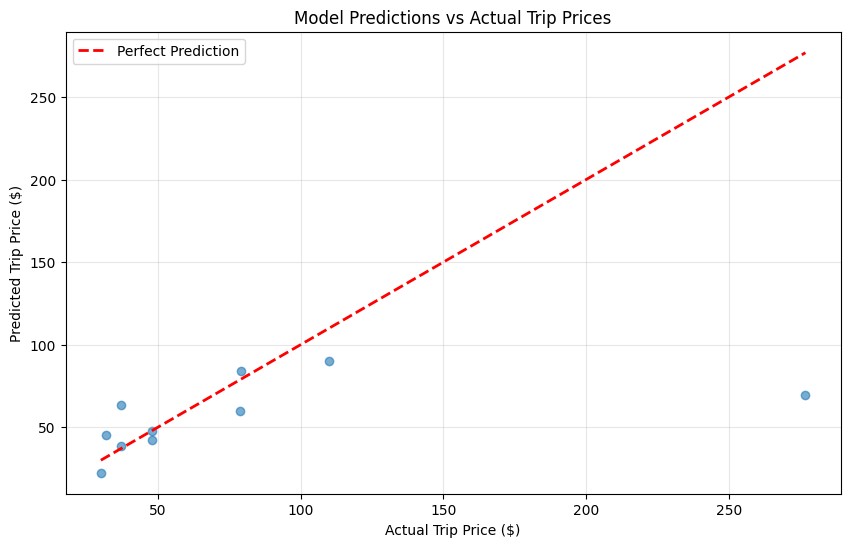


Note: Points closer to the red line indicate better predictions.


In [10]:
# Visualize predictions vs actual
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(actual_prices, predictions_list, alpha=0.6)
plt.plot([min(actual_prices), max(actual_prices)], 
         [min(actual_prices), max(actual_prices)], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Trip Price ($)')
plt.ylabel('Predicted Trip Price ($)')
plt.title('Model Predictions vs Actual Trip Prices')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nNote: Points closer to the red line indicate better predictions.")